# Lab 1: Data Preprocessing and Visualisation

**Aim:** Investigate whether worsening air quality across Indian states may be linked to declining agricultural output by profiling, cleaning, and visualising the provided environmental and agricultural datasets.

The AQI file available in this workspace is `city_day.csv`, and the crop file is `crop_production.csv`. The AQI file contains city-level observations but does not include a `State` column, so a city-to-state mapping is added transparently before merge-readiness checks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

city_raw = pd.read_csv("../datasets/city_day.csv")
crop_raw = pd.read_csv("../datasets/crop_production.csv")

print("city_day.csv:", city_raw.shape)
print("crop_production.csv:", crop_raw.shape)

city_day.csv: (29531, 16)
crop_production.csv: (246091, 7)


In [2]:
print("Displaying all columns in city_raw and crop_raw:")
print(city_raw.columns.tolist())
print(crop_raw.columns.tolist())

Displaying all columns in city_raw and crop_raw:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']


In [3]:
print("Printing first 5 rows of city_raw and crop_raw:")
display(city_raw.head())
display(crop_raw.head())

Printing first 5 rows of city_raw and crop_raw:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [4]:
print("Printing info of city_raw and crop_raw:")
display(city_raw.info())
display(crop_raw.info())

Printing info of city_raw and crop_raw:
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  str    
 1   District_Name  246091 non-null  str    
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  str    
 4   Crop           246091 non-null  str    
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 13.1 MB


None

In [5]:

missing_city_raw = pd.DataFrame({
        "Missing Count": city_raw.isnull().sum(),
        "Missing %": (city_raw.isnull().sum() / len(city_raw)) * 100
    })
print("Missing values in city_raw:")
print(missing_city_raw)

missing_crop_raw = pd.DataFrame({
        "Missing Count": crop_raw.isnull().sum(),
        "Missing %": (crop_raw.isnull().sum() / len(crop_raw)) * 100
    })  
print("Missing values in crop_raw:")
print(missing_crop_raw)

Missing values in city_raw:
            Missing Count  Missing %
City                    0   0.000000
Date                    0   0.000000
PM2.5                4598  15.570079
PM10                11140  37.723071
NO                   3582  12.129626
NO2                  3585  12.139785
NOx                  4185  14.171549
NH3                 10328  34.973418
CO                   2059   6.972334
SO2                  3854  13.050692
O3                   4022  13.619586
Benzene              5623  19.041008
Toluene              8041  27.229014
Xylene              18109  61.322001
AQI                  4681  15.851139
AQI_Bucket           4681  15.851139
Missing values in crop_raw:
               Missing Count  Missing %
State_Name                 0   0.000000
District_Name              0   0.000000
Crop_Year                  0   0.000000
Season                     0   0.000000
Crop                       0   0.000000
Area                       0   0.000000
Production              3730   1.51

In [6]:
print("Chekcing for duplicates in city_raw and crop_raw:")
print(city_raw.duplicated().sum())
print(crop_raw.duplicated().sum())

Chekcing for duplicates in city_raw and crop_raw:
0
0


In [7]:
print("Descriptive statistics for numerical columns:")
display(city_raw.describe())
display(crop_raw.describe())

Descriptive statistics for numerical columns:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [8]:
print("Descriptive statistics for categorical columns:")
display(city_raw.describe(include="object"))
display(crop_raw.describe(include="object"))

Descriptive statistics for categorical columns:


/tmp/ipykernel_38102/2082965009.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(city_raw.describe(include="object"))


,City,Date,AQI_Bucket
count,29531,29531,24850
unique,26,2009,6
top,Ahmedabad,2020-03-11,Moderate
freq,2009,26,8829


/tmp/ipykernel_38102/2082965009.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(crop_raw.describe(include="object"))


,State_Name,District_Name,Season,Crop
count,246091,246091,246091,246091
unique,33,646,6,124
top,Uttar Pradesh,BIJAPUR,Kharif,Rice
freq,33306,945,95951,15104


In [9]:
print("Date/year range in city_raw and crop_raw:")
city_raw["Date"] = pd.to_datetime(city_raw["Date"], errors="coerce")

print("City dataset date range:")
print(city_raw["Date"].min(), "to", city_raw["Date"].max())

print("Crop dataset year range:")
print(crop_raw["Crop_Year"].min(), "to", crop_raw["Crop_Year"].max())

Date/year range in city_raw and crop_raw:
City dataset date range:
2015-01-01 00:00:00 to 2020-07-01 00:00:00
Crop dataset year range:
1997 to 2015


## Task 1: Initial Data Profile

### Structured data profiles

**`city_day.csv`**

| Area checked | First-impression profile |
|---|---|
| Size | 29,531 rows and 16 columns. |
| Unit of observation | One city-day air-quality record. |
| Columns | `City`, `Date`, 12 pollutant measures (`PM2.5`, `PM10`, `NO`, `NO2`, `NOx`, `NH3`, `CO`, `SO2`, `O3`, `Benzene`, `Toluene`, `Xylene`), plus `AQI` and `AQI_Bucket`. |
| Data types | 13 numeric columns and 3 text/date-like columns. `Date` loads as text and must be converted to datetime before time-based analysis. |
| Coverage | 26 cities across 2,009 dates, from 2015-01-01 to 2020-07-01 after parsing `Date`. There is no `State` column in the raw file. |
| Missing values | No missing values in `City` or `Date`, but many pollutant columns have gaps. Important missingness includes `AQI`/`AQI_Bucket`: 4,681 missing each (15.85%), `PM10`: 11,140 (37.72%), `NH3`: 10,328 (34.97%), `Toluene`: 8,041 (27.23%), and `Xylene`: 18,109 (61.32%). |
| Duplicates | 0 duplicate full rows. |
| Categorical summary | `City` has 26 unique values. `AQI_Bucket` has 6 categories; the most frequent category is `Moderate` with 8,829 records. |
| Numerical summary | `AQI` has 24,850 non-null values, mean 166.46, median 118, minimum 13, and maximum 2,049. Several pollutants also have very large maximum values, suggesting possible outliers or severe pollution episodes. |
| Immediate modelling concerns | Missing target values, heavy pollutant missingness, outliers in AQI/pollutants, and missing state information mean the file is not directly ready for state-level modelling or merging. |

**`crop_production.csv`**

| Area checked | First-impression profile |
|---|---|
| Size | 246,091 rows and 7 columns. |
| Unit of observation | One crop-production record for a state, district, crop year, season, and crop. |
| Columns | `State_Name`, `District_Name`, `Crop_Year`, `Season`, `Crop`, `Area`, and `Production`. |
| Data types | 4 text columns (`State_Name`, `District_Name`, `Season`, `Crop`), 1 integer year column, and 2 numeric measurement columns (`Area`, `Production`). |
| Coverage | 33 states/union territories, 646 districts, 124 crops, and 6 seasons. Crop years run from 1997 to 2015. |
| Missing values | Only `Production` has missing values: 3,730 missing records (1.52%). All other columns have 0 missing values. |
| Duplicates | 0 duplicate full rows. |
| Categorical summary | The most frequent state is `Uttar Pradesh` with 33,306 records. The most frequent crop is `Rice` with 15,104 records. The most frequent season is `Kharif` with 95,951 records. |
| Numerical summary | `Area` ranges from 0.04 to 8,580,100, with median 582. `Production` ranges from 0 to 1,250,800,000, with median 729 and mean 582,503.4, showing extreme right skew. |
| Immediate modelling concerns | `Production` is missing in some rows, production values are highly skewed, state names may need standardisation, and the time range ends in 2015, while the AQI file continues to 2020. |

### Concern after inspection

My main concern is that the two datasets cannot be trusted for modelling without careful cleaning and alignment. The AQI file has substantial missingness in both predictor columns and the `AQI` target, and it does not include a state field. The crop file is much larger and cleaner overall, but its `Production` values are extremely skewed and the year range is 1997-2015, while the AQI data runs from 2015-01-01 to 2020-07-01. Any later model linking air quality to crop production would therefore need state mapping, time-window matching, missing-value treatment, and outlier handling before the data could be used responsibly.

In [10]:
display(city_raw.describe(include="all").T)
display(crop_raw.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,NaN,NaN,NaN,2018-05-14 05:40:15.807118,2015-01-01 00:00:00,2017-04-16 00:00:00,2018-08-05 00:00:00,2019-09-03 00:00:00,2020-07-01 00:00:00,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,0.04,28.82,48.57,80.59,949.99,64.661449
PM10,18391.0,NaN,NaN,NaN,118.127103,0.01,56.255,95.68,149.745,1000.0,90.60511
NO,25949.0,NaN,NaN,NaN,17.57473,0.02,5.63,9.89,19.95,390.68,22.785846
NO2,25946.0,NaN,NaN,NaN,28.560659,0.01,11.75,21.69,37.62,362.21,24.474746
NOx,25346.0,NaN,NaN,NaN,32.309123,0.0,12.82,23.52,40.1275,467.63,31.646011
NH3,19203.0,NaN,NaN,NaN,23.483476,0.01,8.58,15.85,30.02,352.89,25.684275
CO,27472.0,NaN,NaN,NaN,2.248598,0.0,0.51,0.89,1.45,175.81,6.962884
SO2,25677.0,NaN,NaN,NaN,14.531977,0.01,5.67,9.16,15.22,193.86,18.133775


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State_Name,246091,33,Uttar Pradesh,33306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District_Name,246091,646,BIJAPUR,945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,246091.0,NaN,NaN,NaN,2005.643018,4.952164,1997.0,2002.0,2006.0,2010.0,2015.0
Season,246091,6,Kharif,95951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,246091,124,Rice,15104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,246091.0,NaN,NaN,NaN,12002.820864,50523.404019,0.04,80.0,582.0,4392.0,8580100.0
Production,242361.0,NaN,NaN,NaN,582503.442251,17065813.17241,0.0,88.0,729.0,7023.0,1250800000.0


In [11]:
def profile_dataframe(df, name):
    profile = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "unique": df.nunique(dropna=True).values,
    })
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")
    print(f"Duplicate full rows: {df.duplicated().sum():,}")
    display(profile)
    display(df.head())
    numeric_cols = df.select_dtypes(include="number").columns
    if len(numeric_cols):
        display(df[numeric_cols].describe().T)

profile_dataframe(city_raw, "city_day.csv profile")
profile_dataframe(crop_raw, "crop_production.csv profile")

city_dates = pd.to_datetime(city_raw["Date"], errors="coerce")
print("AQI date range:", city_dates.min().date(), "to", city_dates.max().date())
print("Crop year range:", crop_raw["Crop_Year"].min(), "to", crop_raw["Crop_Year"].max())


city_day.csv profile
--------------------
Rows: 29,531
Columns: 16
Duplicate full rows: 0


,column,dtype,non_null,missing,missing_pct,unique
0,City,str,29531,0,0.00,26
1,Date,datetime64[us],29531,0,0.00,2009
2,PM2.5,float64,24933,4598,15.57,11716
3,PM10,float64,18391,11140,37.72,12571
4,NO,float64,25949,3582,12.13,5776
5,NO2,float64,25946,3585,12.14,7404
6,NOx,float64,25346,4185,14.17,8156
7,NH3,float64,19203,10328,34.97,5922
8,CO,float64,27472,2059,6.97,1779
9,SO2,float64,25677,3854,13.05,4761


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73
Benzene,23908.0,3.280840,15.811136,0.00,0.120,1.07,3.0800,455.03



crop_production.csv profile
---------------------------
Rows: 246,091
Columns: 7
Duplicate full rows: 0


,column,dtype,non_null,missing,missing_pct,unique
0,State_Name,str,246091,0,0.00,33
1,District_Name,str,246091,0,0.00,646
2,Crop_Year,int64,246091,0,0.00,19
3,Season,str,246091,0,0.00,6
4,Crop,str,246091,0,0.00,124
5,Area,float64,246091,0,0.00,38442
6,Production,float64,242361,3730,1.52,51627


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


,count,mean,std,min,25%,50%,75%,max
Crop_Year,246091.0,2005.643018,4.952164e+00,1997.00,2002.0,2006.0,2010.0,2.015000e+03
Area,246091.0,12002.820864,5.052340e+04,0.04,80.0,582.0,4392.0,8.580100e+06
Production,242361.0,582503.442251,1.706581e+07,0.00,88.0,729.0,7023.0,1.250800e+09


AQI date range: 2015-01-01 to 2020-07-01
Crop year range: 1997 to 2015


## Task 2: Missing Value Treatment Strategy

Missing values should not all be treated the same way. Dropping every row with any null value would remove too much AQI data, while filling every column with the mean would be unsafe because pollution and production values are skewed and contain extreme values. My strategy is to drop missing target/output values and impute missing predictor values with medians, which are less affected by outliers than means.

### `city_day.csv` decisions

| Column | Missing values | Treatment | Justification |
|---|---:|---|---|
| `PM2.5` | 4,598 | Impute with city-wise median, then overall median if needed | Important pollutant predictor with moderate missingness. Median is preferred because pollutant values are skewed and can contain spikes. |
| `PM10` | 11,140 | Impute with city-wise median, then overall median if needed | Missingness is high, so deleting affected rows would waste too much data. City-wise median keeps local pollution patterns better than one overall mean. |
| `NO` | 3,582 | Impute with city-wise median, then overall median if needed | Useful pollutant predictor with manageable missingness. Median avoids distortion from extreme readings. |
| `NO2` | 3,585 | Impute with city-wise median, then overall median if needed | Same reasoning as `NO`: keep the feature and use a robust location value. |
| `NOx` | 4,185 | Impute with city-wise median, then overall median if needed | Related nitrogen oxide measure, useful for AQI analysis. Median imputation is safer than mean imputation. |
| `NH3` | 10,328 | Impute with city-wise median, then overall median if needed | High missingness, but dropping rows would remove many otherwise usable observations. Keep it with cautious median imputation. |
| `CO` | 2,059 | Impute with city-wise median, then overall median if needed | Relatively low missingness among pollutant columns, so keeping and imputing is reasonable. |
| `SO2` | 3,854 | Impute with city-wise median, then overall median if needed | Moderate missingness and a relevant pollutant feature. Median handles skew better than mean. |
| `O3` | 4,022 | Impute with city-wise median, then overall median if needed | Moderate missingness. Use city-wise median to preserve city-level differences. |
| `Benzene` | 5,623 | Impute with city-wise median, then overall median if needed | Missingness is not small, but the column can still provide pollutant information. Median reduces outlier influence. |
| `Toluene` | 8,041 | Impute with city-wise median, then overall median if needed | High missingness, but still less damaging than deleting many AQI rows. Median imputation is used cautiously. |
| `Xylene` | 18,109 | Impute with city-wise median, then overall median if needed, but flag as weak | This has the worst missingness at 61.32%, so it is less reliable. I keep it to preserve the existing pollutant set, but any later modelling should treat it cautiously. |
| `AQI` | 4,681 | Drop affected rows | `AQI` is the main outcome/target variable. Imputing it would create artificial labels and bias later analysis. |
| `AQI_Bucket` | 4,681 | Rebuild after dropping missing `AQI` | `AQI_Bucket` is derived from `AQI`, so it should be regenerated from the cleaned numeric AQI values instead of separately imputed. |

`City` and `Date` have no missing values. `Date` is still converted to datetime so that later time-based analysis is reliable.

### `crop_production.csv` decisions

| Column | Missing values | Treatment | Justification |
|---|---:|---|---|
| `Production` | 3,730 | Drop affected rows | Only 1.52% of crop rows are missing production, so the data loss is small. `Production` is the main output variable in the crop file, and imputing it would create artificial production values. Dropping is cleaner and less biased here. |

`State_Name`, `District_Name`, `Crop_Year`, `Season`, `Crop`, and `Area` have no missing values, so no missing-value treatment is required for those columns.

### Verification plan

The code below stores null counts before treatment, applies the strategy, and then displays before-and-after null counts. For the crop file, it also prints the number of rows before and after dropping missing `Production`, so the evidence shows both that nulls were removed and how much data was lost.

In [12]:
city_missing_before = city_raw.isna().sum().rename("before")
crop_missing_before = crop_raw.isna().sum().rename("before")

city_clean = city_raw.copy()
city_clean["Date"] = pd.to_datetime(city_clean["Date"], errors="coerce")
city_clean = city_clean.dropna(subset=["AQI"]).copy()

pollutant_cols = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2",
    "O3", "Benzene", "Toluene", "Xylene"
]

for col in pollutant_cols:
    city_clean[col] = city_clean[col].fillna(
        city_clean.groupby("City")[col].transform("median")
    )
    city_clean[col] = city_clean[col].fillna(city_clean[col].median())

def aqi_bucket(aqi):
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50:
        return "Good"
    if aqi <= 100:
        return "Satisfactory"
    if aqi <= 200:
        return "Moderate"
    if aqi <= 300:
        return "Poor"
    if aqi <= 400:
        return "Very Poor"
    return "Severe"

city_clean["AQI_Bucket"] = city_clean["AQI"].apply(aqi_bucket)

crop_clean = crop_raw.dropna(subset=["Production"]).copy()

city_missing_after = city_clean.isna().sum().rename("after")
crop_missing_after = crop_clean.isna().sum().rename("after")

print("AQI missing values before and after treatment")
display(pd.concat([city_missing_before, city_missing_after], axis=1).fillna(0).astype(int))

print("Crop missing values before and after treatment")
display(pd.concat([crop_missing_before, crop_missing_after], axis=1).fillna(0).astype(int))

print(f"Crop rows before treatment: {len(crop_raw):,}")
print(f"Crop rows after dropping missing Production: {len(crop_clean):,}")
print(f"Rows dropped: {len(crop_raw) - len(crop_clean):,}")

AQI missing values before and after treatment


,before,after
City,0,0
Date,0,0
PM2.5,4598,0
PM10,11140,0
NO,3582,0
NO2,3585,0
NOx,4185,0
NH3,10328,0
CO,2059,0
SO2,3854,0


Crop missing values before and after treatment


,before,after
State_Name,0,0
District_Name,0,0
Crop_Year,0,0
Season,0,0
Crop,0,0
Area,0,0
Production,3730,0


Crop rows before treatment: 246,091
Crop rows after dropping missing Production: 242,361
Rows dropped: 3,730


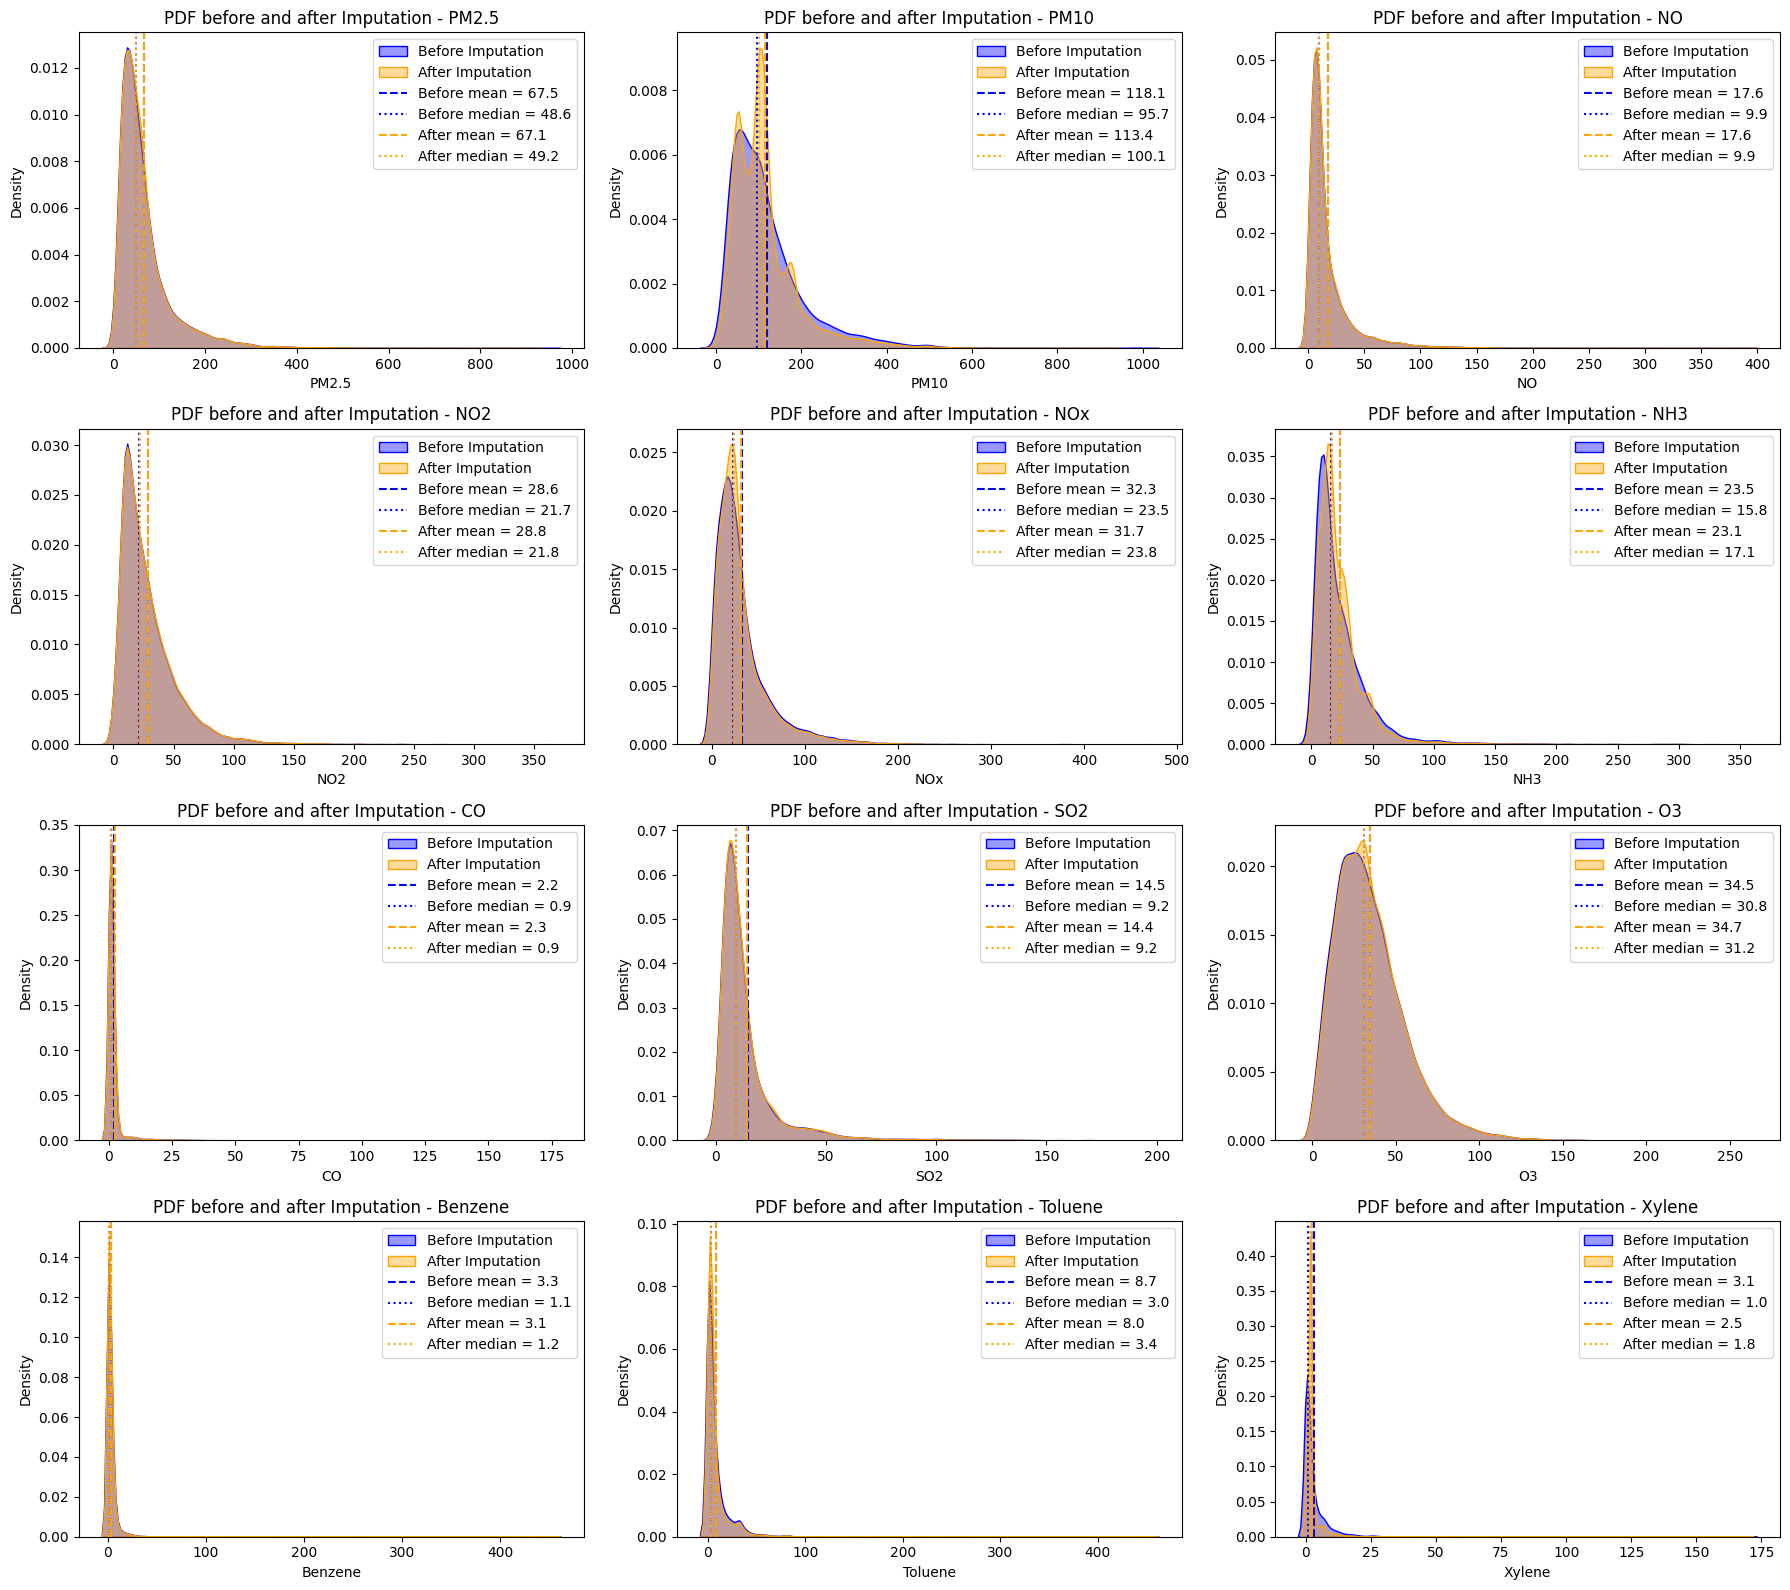

In [13]:
# Plotting the PDF before and after imputation for each pollutant
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    before_mean = city_raw[col].mean()
    before_median = city_raw[col].median()
    after_mean = city_clean[col].mean()
    after_median = city_clean[col].median()

    sns.kdeplot(data=city_raw, x=col, ax=axes[i], label="Before Imputation", fill=True, alpha=0.4, color="blue")
    sns.kdeplot(data=city_clean, x=col, ax=axes[i], label="After Imputation", fill=True, alpha=0.4, color="orange")
    axes[i].axvline(before_mean, color="blue", linestyle="--", linewidth=1.5, label=f"Before mean = {before_mean:.1f}")
    axes[i].axvline(before_median, color="blue", linestyle=":", linewidth=1.5, label=f"Before median = {before_median:.1f}")
    axes[i].axvline(after_mean, color="orange", linestyle="--", linewidth=1.5, label=f"After mean = {after_mean:.1f}")
    axes[i].axvline(after_median, color="orange", linestyle=":", linewidth=1.5, label=f"After median = {after_median:.1f}")
    axes[i].set_title(f"PDF before and after Imputation - {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.tight_layout()
plt.show()

## Task 3: Standardise State Names and Remove Redundant Records

If state names differ by spelling, whitespace, or old names, an exact merge will silently fail and create missing matches. To avoid that, I standardise state names before merging by stripping leading/trailing spaces, collapsing repeated spaces, and applying a small dictionary of known renamed states/alternate names. I also check for duplicate records using both full-row duplicates and practical merge keys.

### Inconsistencies found and fixes applied

| File | Inconsistency found | Fix applied |
|---|---|---|
| `crop_production.csv` | `Jammu and Kashmir ` has a trailing space. | Strip whitespace to standardise it as `Jammu and Kashmir`. |
| `crop_production.csv` | `Telangana ` has a trailing space. | Strip whitespace to standardise it as `Telangana`. |
| `city_day.csv` | No raw `State` column exists, even though state is needed as the merge key. | Derive `State` from a documented `City` to `State` mapping. |
| Both files | Possible old/alternate state names can break exact matching if they appear. | Handle known variants defensively: `Orissa` -> `Odisha`, `Pondicherry` -> `Puducherry`, `Uttaranchal` -> `Uttarakhand`, and `NCT of Delhi` -> `Delhi`. These variants were included as safeguards; the actual raw crop file only showed the two trailing-space issues above. |

### Merge-readiness checks

- Check that every AQI city maps to a state.
- Compare state names after standardisation to see which states are shared and which are present in only one file.
- Remove redundant records using full-row duplicates first.
- Remove practical key duplicates next: `City` + `Date` for AQI, and `State` + `District_Name` + `Crop_Year` + `Season` + `Crop` for crop records.
- Show record counts before and after duplicate removal as evidence.

In [14]:
import re

city_state_map = {
    "Ahmedabad": "Gujarat",
    "Aizawl": "Mizoram",
    "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab",
    "Bengaluru": "Karnataka",
    "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha",
    "Chandigarh": "Chandigarh",
    "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu",
    "Delhi": "Delhi",
    "Ernakulam": "Kerala",
    "Gurugram": "Haryana",
    "Guwahati": "Assam",
    "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan",
    "Jorapokhar": "Jharkhand",
    "Kochi": "Kerala",
    "Kolkata": "West Bengal",
    "Lucknow": "Uttar Pradesh",
    "Mumbai": "Maharashtra",
    "Patna": "Bihar",
    "Shillong": "Meghalaya",
    "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala",
    "Visakhapatnam": "Andhra Pradesh",
}

known_state_fixes = {
    "Orissa": "Odisha",
    "Pondicherry": "Puducherry",
    "Uttaranchal": "Uttarakhand",
    "Nct Of Delhi": "Delhi",
    "NCT of Delhi": "Delhi",
}

def clean_state_name(value):
    if pd.isna(value):
        return value
    cleaned = re.sub(r"\s+", " ", str(value).strip())
    return known_state_fixes.get(cleaned, cleaned)

city_merge_ready = city_clean.copy()
city_merge_ready["State"] = city_merge_ready["City"].map(city_state_map)
unmapped_cities = sorted(city_merge_ready.loc[city_merge_ready["State"].isna(), "City"].unique())
print("Unmapped AQI cities:", unmapped_cities)

crop_merge_ready = crop_clean.copy()
crop_merge_ready["State"] = crop_merge_ready["State_Name"].apply(clean_state_name)

state_fix_report = (
    crop_clean.assign(State=crop_merge_ready["State"])
    .loc[lambda df: df["State_Name"] != df["State"]]
    .groupby(["State_Name", "State"], as_index=False)
    .size()
    .rename(columns={"State_Name": "raw_state_name", "State": "standardised_state", "size": "records_affected"})
    .sort_values(["raw_state_name", "standardised_state"])
)
print("State-name inconsistencies found in crop data")
display(state_fix_report)

city_before = len(city_merge_ready)
crop_before = len(crop_merge_ready)
city_full_dupes_before = city_merge_ready.duplicated().sum()
crop_full_dupes_before = crop_merge_ready.duplicated().sum()
city_key_dupes_before = city_merge_ready.duplicated(["City", "Date"]).sum()
crop_key_dupes_before = crop_merge_ready.duplicated(["State", "District_Name", "Crop_Year", "Season", "Crop"]).sum()

city_merge_ready = city_merge_ready.drop_duplicates().drop_duplicates(["City", "Date"])
crop_merge_ready = crop_merge_ready.drop_duplicates().drop_duplicates(
    ["State", "District_Name", "Crop_Year", "Season", "Crop"]
)
city_full_dupes_after = city_merge_ready.duplicated().sum()
crop_full_dupes_after = crop_merge_ready.duplicated().sum()
city_key_dupes_after = city_merge_ready.duplicated(["City", "Date"]).sum()
crop_key_dupes_after = crop_merge_ready.duplicated(["State", "District_Name", "Crop_Year", "Season", "Crop"]).sum()

duplicate_evidence = pd.DataFrame({
    "dataset": ["AQI", "Crop"],
    "records_before": [city_before, crop_before],
    "full_row_duplicates_before": [city_full_dupes_before, crop_full_dupes_before],
    "key_duplicates_before": [city_key_dupes_before, crop_key_dupes_before],
    "records_after": [len(city_merge_ready), len(crop_merge_ready)],
    "full_row_duplicates_after": [city_full_dupes_after, crop_full_dupes_after],
    "key_duplicates_after": [city_key_dupes_after, crop_key_dupes_after],
    "records_removed": [city_before - len(city_merge_ready), crop_before - len(crop_merge_ready)],
})
print("Duplicate removal evidence")
display(duplicate_evidence)

aqi_states = set(city_merge_ready["State"].dropna())
crop_states = set(crop_merge_ready["State"].dropna())
merge_state_check = pd.DataFrame({
    "Shared_states_available_for_merge": [sorted(aqi_states & crop_states)],
    "AQI_states_not_in_crop": [sorted(aqi_states - crop_states)],
    "Crop_states_not_in_AQI": [sorted(crop_states - aqi_states)],
})
print("State merge-readiness check")
display(merge_state_check)

Unmapped AQI cities: []
State-name inconsistencies found in crop data


,raw_state_name,standardised_state,records_affected
0,Jammu and Kashmir,Jammu and Kashmir,1632
1,Telangana,Telangana,5591


Duplicate removal evidence


,dataset,records_before,full_row_duplicates_before,key_duplicates_before,records_after,full_row_duplicates_after,key_duplicates_after,records_removed
0,AQI,24850,0,0,24850,0,0,0
1,Crop,242361,0,0,242361,0,0,0


State merge-readiness check


,Shared_states_available_for_merge,AQI_states_not_in_crop,Crop_states_not_in_AQI
0,"[Andhra Pradesh, Assam, Bihar, Chandigarh, Guj...",[Delhi],"[Andaman and Nicobar Islands, Arunachal Prades..."


## Task 4: AQI Distribution

I use a histogram to show where AQI values cluster and a boxplot to reveal whether extreme values are stretching the distribution. The histogram answers whether most cities/days are moderate or worse; the boxplot directly addresses whether the mean may be pulled upward by unusually high readings.

### Observations

1. The AQI distribution is right-skewed: the median is lower than the mean, which means a small number of high-pollution observations pull the average upward.
2. Most valid readings sit in the `Satisfactory` to `Moderate` range, but the long upper tail and many severe readings show that pollution is not only a few isolated points; extreme city-days still matter for public reporting.

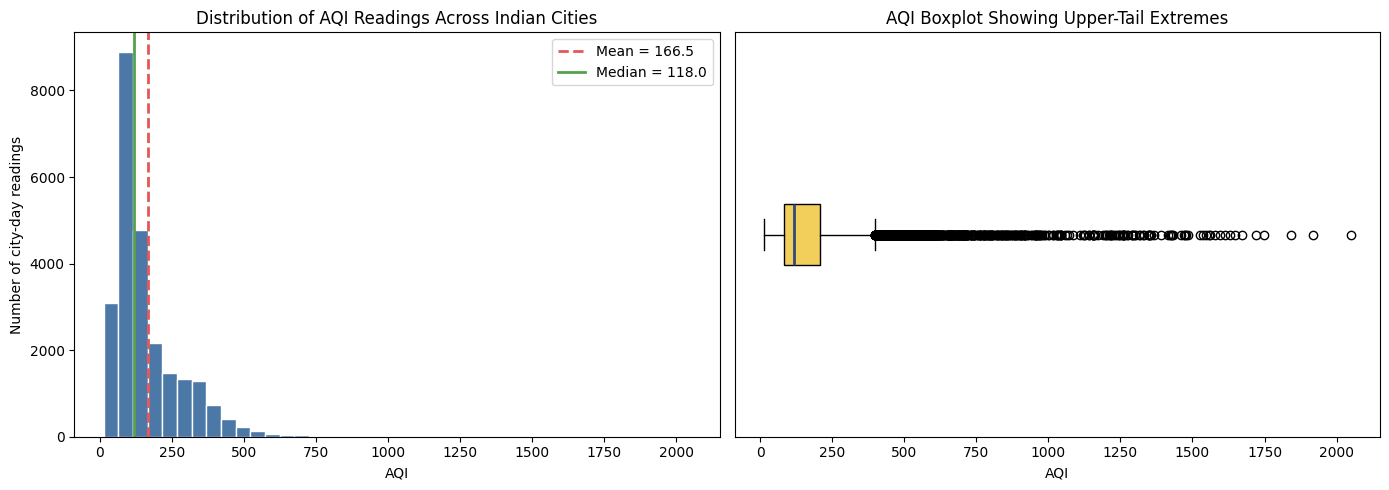

,count,percent
AQI_Bucket,,
Good,1341,5.40
Satisfactory,8224,33.09
Moderate,8829,35.53
Poor,2781,11.19
Very Poor,2337,9.40
Severe,1338,5.38


Mean AQI: 166.46
Median AQI: 118.00


In [15]:
aqi_before_outlier_treatment = city_merge_ready["AQI"].dropna()

mean_aqi = aqi_before_outlier_treatment.mean()
median_aqi = aqi_before_outlier_treatment.median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aqi_before_outlier_treatment, bins=40, color="#4C78A8", edgecolor="white")
axes[0].axvline(mean_aqi, color="#E45756", linestyle="--", linewidth=2, label=f"Mean = {mean_aqi:.1f}")
axes[0].axvline(median_aqi, color="#54A24B", linestyle="-", linewidth=2, label=f"Median = {median_aqi:.1f}")
axes[0].set_title("Distribution of AQI Readings Across Indian Cities")
axes[0].set_xlabel("AQI")
axes[0].set_ylabel("Number of city-day readings")
axes[0].legend()

axes[1].boxplot(aqi_before_outlier_treatment, vert=False, patch_artist=True,
                boxprops={"facecolor": "#F2CF5B"}, medianprops={"color": "#2F4B7C", "linewidth": 2})
axes[1].set_title("AQI Boxplot Showing Upper-Tail Extremes")
axes[1].set_xlabel("AQI")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

bucket_counts = city_merge_ready["AQI_Bucket"].value_counts().reindex(
    ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
)
display(bucket_counts.to_frame("count").assign(percent=lambda x: (x["count"] / x["count"].sum() * 100).round(2)))
print(f"Mean AQI: {mean_aqi:.2f}")
print(f"Median AQI: {median_aqi:.2f}")

## Task 5: Extreme AQI Values

The Indian AQI scale is normally reported from 0 to 500, with values above 400 classed as severe. Therefore, values above 500 are treated as implausibly high for this analysis. I use a rule-based threshold instead of an IQR rule because the problem statement specifically says some AQI readings are physically/reporting-wise implausible, not merely statistically unusual.

**Treatment chosen:** cap AQI values above 500 at 500. This winsorisation keeps the fact that those observations were extremely polluted while preventing impossible values such as 1000+ from distorting averages, plots, and later models. Deleting them would remove severe pollution events entirely.

Extreme AQI values above 500: 543 (2.19% of cleaned AQI records)
95th percentile AQI: 407.0
End of distribution treatment: Yes


,City,State,Date,AQI,AQI_capped
30,Ahmedabad,Gujarat,2015-01-31,514.0,500.0
31,Ahmedabad,Gujarat,2015-02-01,782.0,500.0
32,Ahmedabad,Gujarat,2015-02-02,914.0,500.0
33,Ahmedabad,Gujarat,2015-02-03,660.0,500.0
43,Ahmedabad,Gujarat,2015-02-13,510.0,500.0
44,Ahmedabad,Gujarat,2015-02-14,761.0,500.0
46,Ahmedabad,Gujarat,2015-02-16,536.0,500.0
48,Ahmedabad,Gujarat,2015-02-18,592.0,500.0
50,Ahmedabad,Gujarat,2015-02-20,588.0,500.0
51,Ahmedabad,Gujarat,2015-02-21,1141.0,500.0


,Before treatment,After capping at 500
count,24850.000000,24850.000000
mean,166.463581,160.920684
std,140.696585,113.180357
min,13.000000,13.000000
25%,81.000000,81.000000
50%,118.000000,118.000000
75%,208.000000,208.000000
max,2049.000000,500.000000


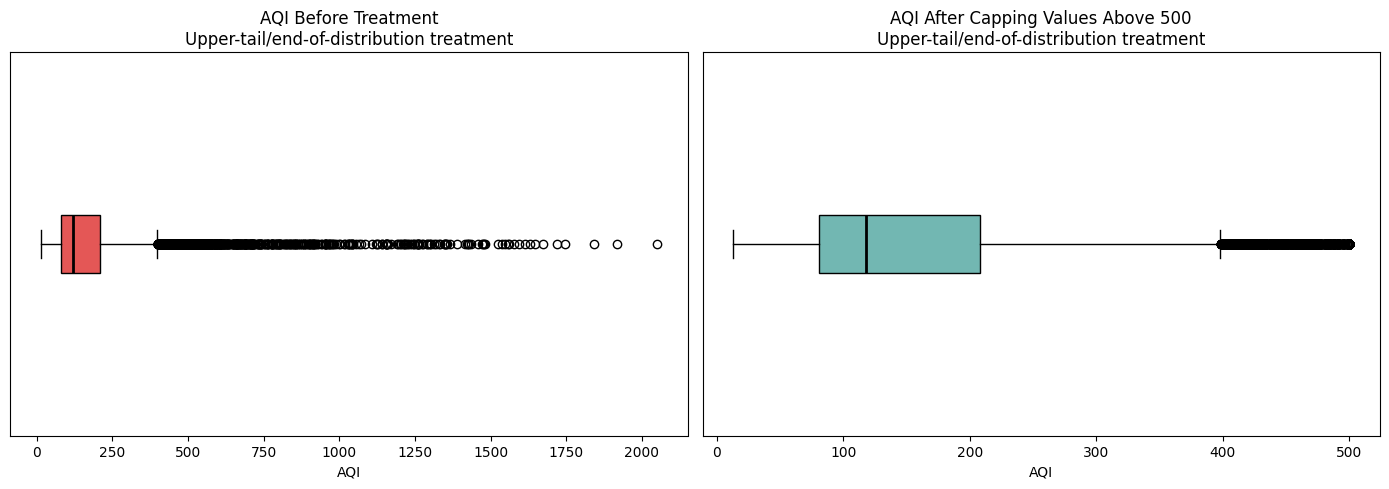

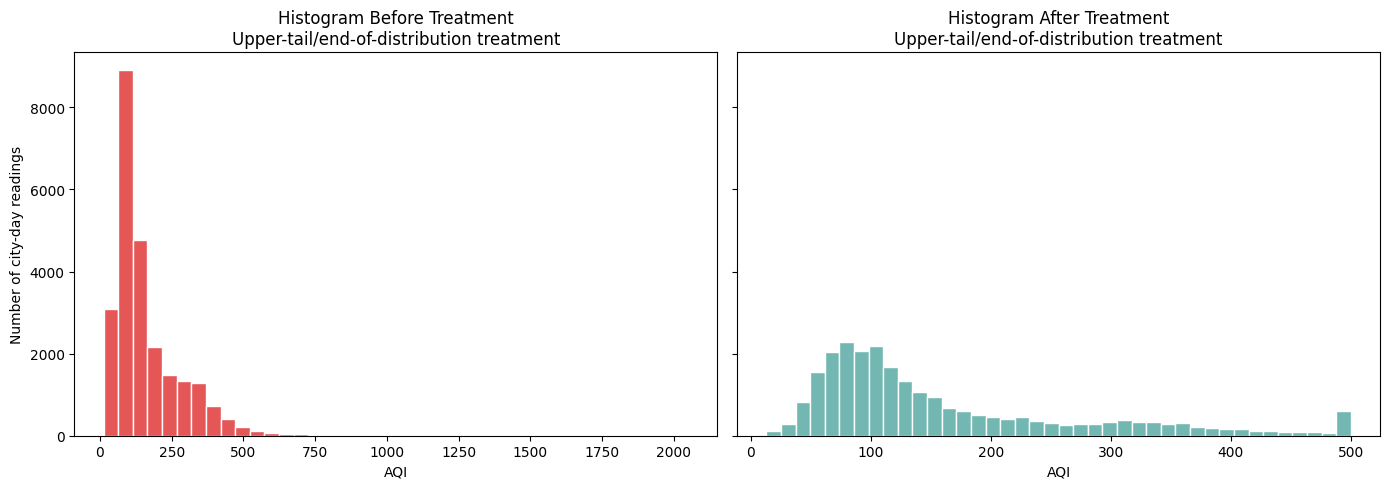

In [16]:
AQI_UPPER_LIMIT = 500

city_final = city_merge_ready.copy()
extreme_mask = city_final["AQI"] > AQI_UPPER_LIMIT
extreme_count = int(extreme_mask.sum())
extreme_percent = extreme_count / len(city_final) * 100
upper_tail_cutoff = city_final["AQI"].quantile(0.95)
is_end_of_distribution = extreme_count > 0 and city_final.loc[extreme_mask, "AQI"].min() >= upper_tail_cutoff
tail_note = "Upper-tail/end-of-distribution treatment" if is_end_of_distribution else "Extreme-value treatment"

city_final["AQI_capped"] = city_final["AQI"].clip(upper=AQI_UPPER_LIMIT)
city_final["AQI_Bucket_Clean"] = city_final["AQI_capped"].apply(aqi_bucket)

print(f"Extreme AQI values above {AQI_UPPER_LIMIT}: {extreme_count:,} ({extreme_percent:.2f}% of cleaned AQI records)")
print(f"95th percentile AQI: {upper_tail_cutoff:.1f}")
print(f"End of distribution treatment: {'Yes' if is_end_of_distribution else 'No'}")
display(city_final.loc[extreme_mask, ["City", "State", "Date", "AQI", "AQI_capped"]].head(10))

comparison_stats = pd.DataFrame({
    "Before treatment": city_final["AQI"].describe(),
    "After capping at 500": city_final["AQI_capped"].describe(),
})
display(comparison_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].boxplot(city_final["AQI"], vert=False, patch_artist=True,
                boxprops={"facecolor": "#E45756"}, medianprops={"color": "black", "linewidth": 2})
axes[0].set_title(f"AQI Before Treatment\n{tail_note}")
axes[0].set_xlabel("AQI")
axes[0].set_yticks([])

axes[1].boxplot(city_final["AQI_capped"], vert=False, patch_artist=True,
                boxprops={"facecolor": "#72B7B2"}, medianprops={"color": "black", "linewidth": 2})
axes[1].set_title(f"AQI After Capping Values Above 500\n{tail_note}")
axes[1].set_xlabel("AQI")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(city_final["AQI"], bins=40, color="#E45756", edgecolor="white")
axes[0].set_title(f"Histogram Before Treatment\n{tail_note}")
axes[0].set_xlabel("AQI")
axes[0].set_ylabel("Number of city-day readings")

axes[1].hist(city_final["AQI_capped"], bins=40, color="#72B7B2", edgecolor="white")
axes[1].set_title(f"Histogram After Treatment\n{tail_note}")
axes[1].set_xlabel("AQI")

plt.tight_layout()
plt.show()

## Extra Visualizations for Tasks 1-5

These plots support the preprocessing and visual exploration tasks completed before the time-trend analysis. They summarise dataset completeness, missing-value treatment, merge readiness, AQI bucket composition, and the effect of capping extreme AQI values.

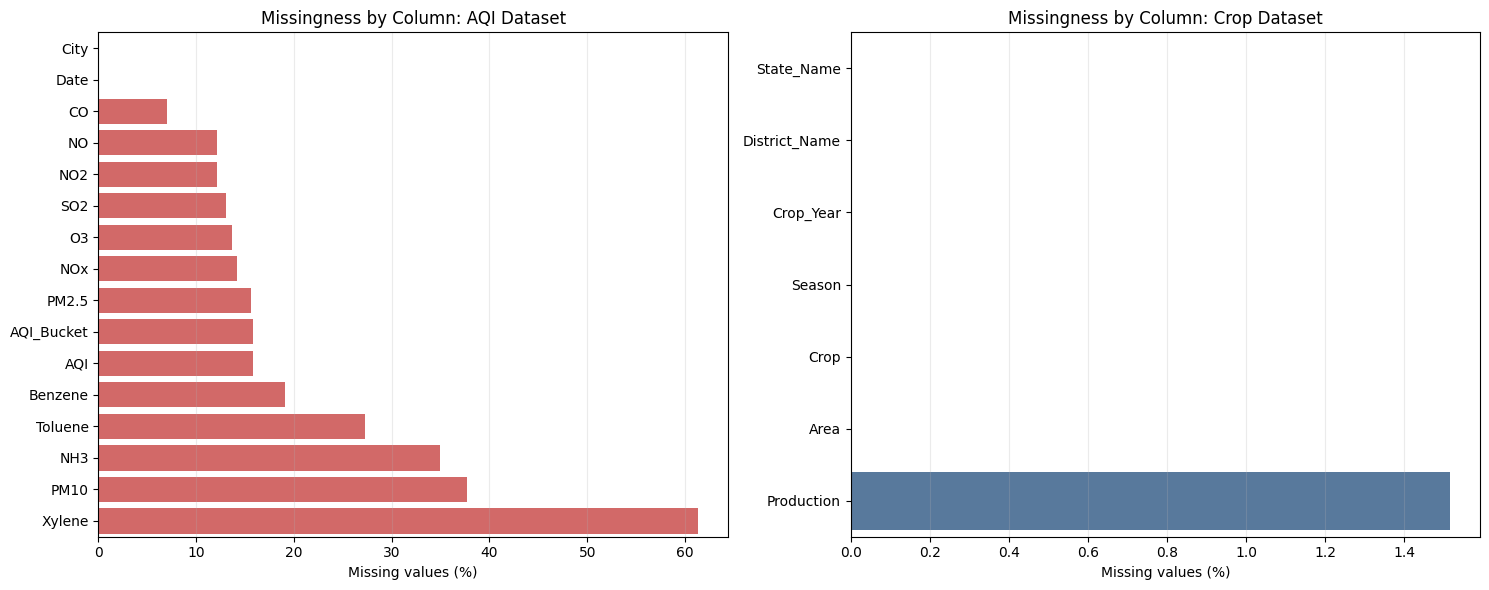

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

city_missing_profile = (
    missing_city_raw["Missing %"]
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={"index": "Column", "Missing %": "Missing percent"})
)

crop_missing_profile = (
    missing_crop_raw["Missing %"]
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={"index": "Column", "Missing %": "Missing percent"})
)

sns.barplot(data=city_missing_profile, x="Missing percent", y="Column", color="#E45756", ax=axes[0])
axes[0].set_title("Missingness by Column: AQI Dataset")
axes[0].set_xlabel("Missing values (%)")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

sns.barplot(data=crop_missing_profile, x="Missing percent", y="Column", color="#4C78A8", ax=axes[1])
axes[1].set_title("Missingness by Column: Crop Dataset")
axes[1].set_xlabel("Missing values (%)")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

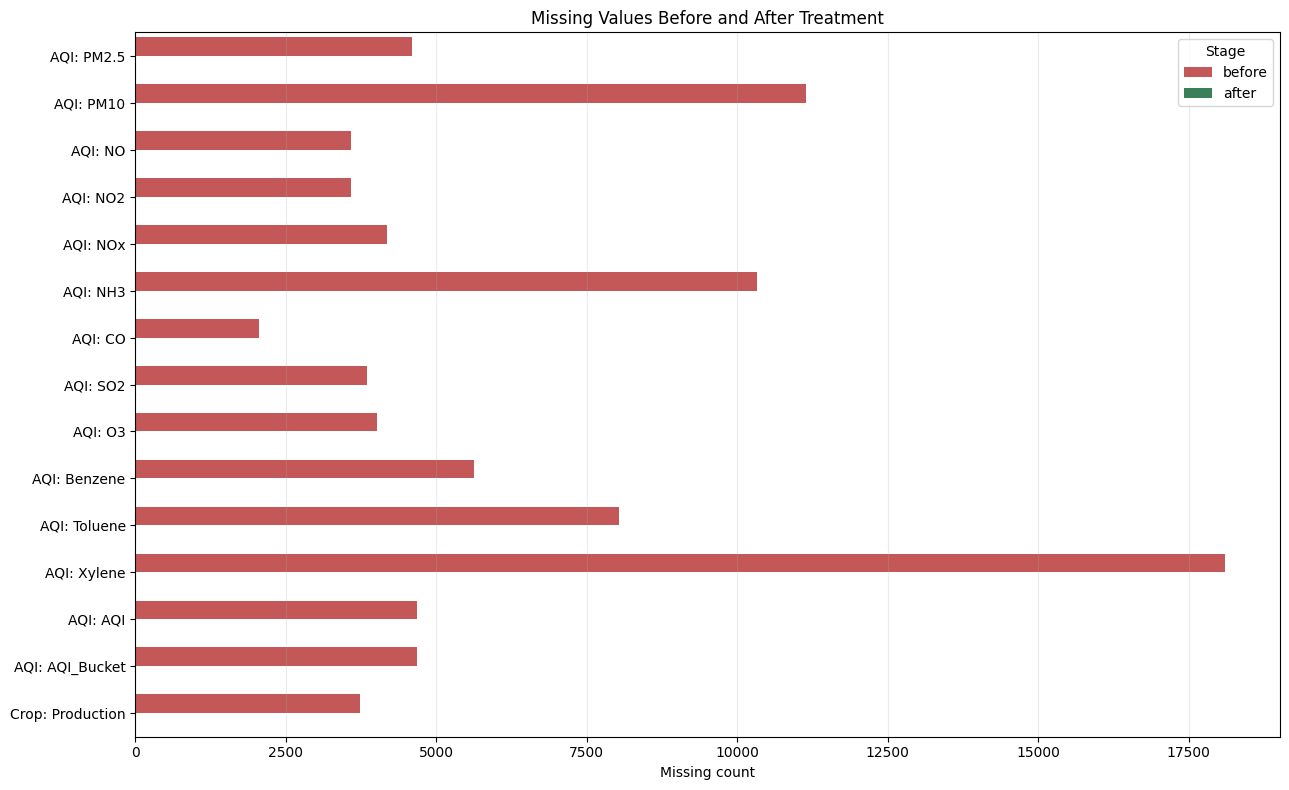

In [18]:
missing_treatment_summary = pd.concat(
    [
        pd.concat([city_missing_before, city_missing_after], axis=1)
        .fillna(0)
        .assign(dataset="AQI"),
        pd.concat([crop_missing_before, crop_missing_after], axis=1)
        .fillna(0)
        .assign(dataset="Crop"),
    ]
).reset_index().rename(columns={"index": "Column"})

missing_treatment_long = missing_treatment_summary.melt(
    id_vars=["dataset", "Column"],
    value_vars=["before", "after"],
    var_name="Stage",
    value_name="Missing count",
)
missing_treatment_long["Label"] = missing_treatment_long["dataset"] + ": " + missing_treatment_long["Column"]
missing_treatment_long = missing_treatment_long[missing_treatment_long.groupby("Label")["Missing count"].transform("max") > 0]

fig, ax = plt.subplots(figsize=(13, 8))
sns.barplot(
    data=missing_treatment_long,
    x="Missing count",
    y="Label",
    hue="Stage",
    palette={"before": "#D64545", "after": "#2E8B57"},
    ax=ax,
)
ax.set_title("Missing Values Before and After Treatment")
ax.set_xlabel("Missing count")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

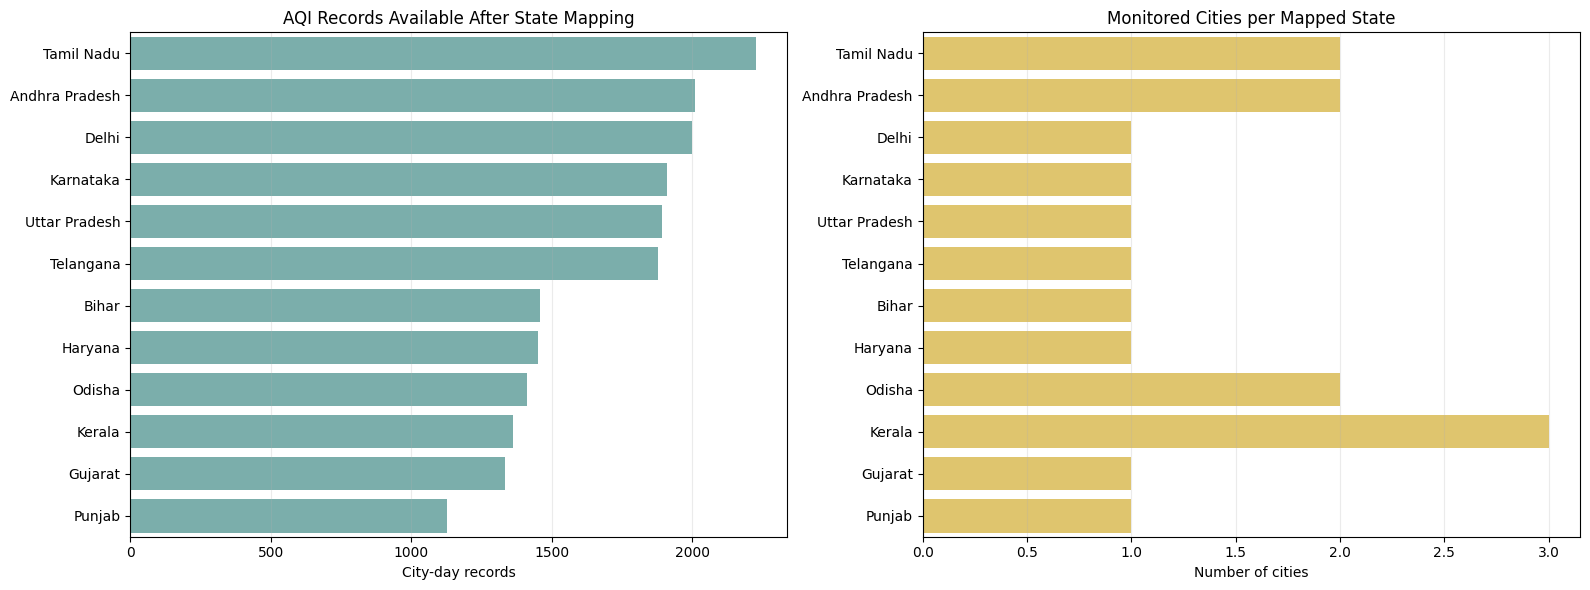

,State,records,cities
0,Tamil Nadu,2228,2
1,Andhra Pradesh,2012,2
2,Delhi,1999,1
3,Karnataka,1910,1
4,Uttar Pradesh,1893,1
5,Telangana,1880,1
6,Bihar,1459,1
7,Haryana,1453,1
8,Odisha,1411,2
9,Kerala,1363,3


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_counts = (
    city_merge_ready.groupby("State")
    .agg(records=("AQI", "size"), cities=("City", "nunique"))
    .sort_values("records", ascending=False)
    .reset_index()
)

sns.barplot(data=state_counts.head(12), x="records", y="State", color="#72B7B2", ax=axes[0])
axes[0].set_title("AQI Records Available After State Mapping")
axes[0].set_xlabel("City-day records")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

sns.barplot(data=state_counts.head(12), x="cities", y="State", color="#F2CF5B", ax=axes[1])
axes[1].set_title("Monitored Cities per Mapped State")
axes[1].set_xlabel("Number of cities")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

display(state_counts.head(12))

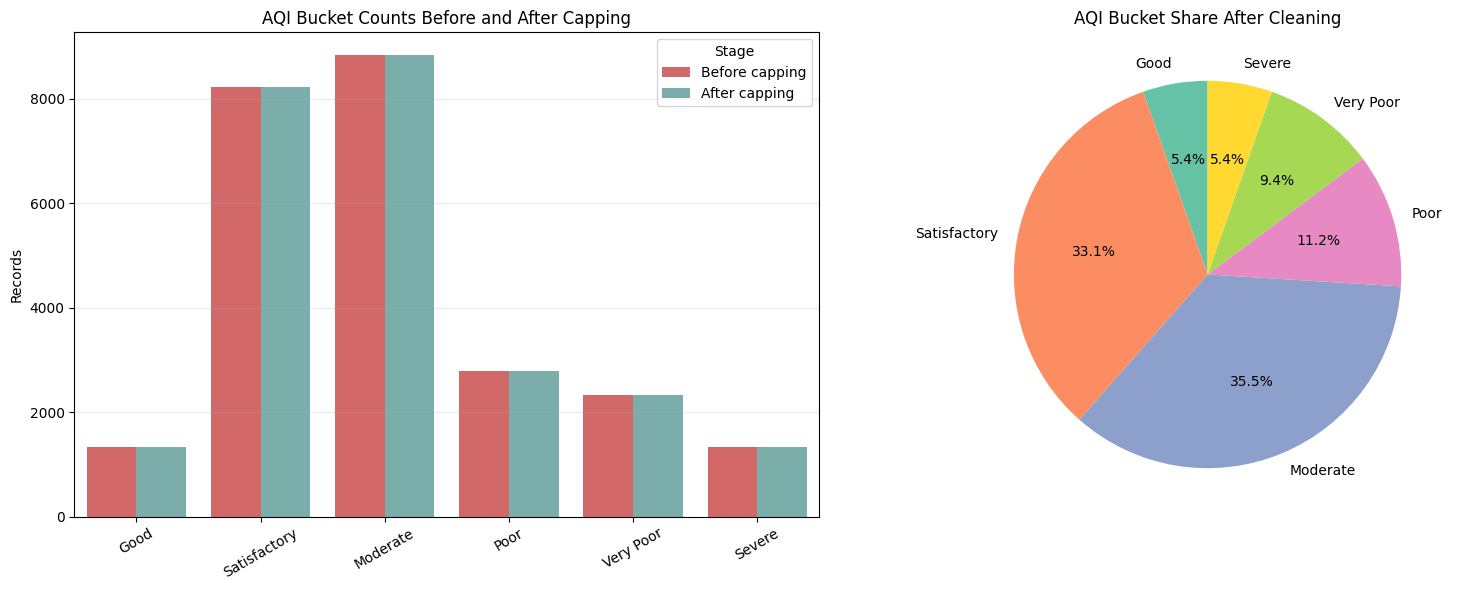

,AQI bucket,Before capping,After capping
0,Good,1341,1341
1,Satisfactory,8224,8224
2,Moderate,8829,8829
3,Poor,2781,2781
4,Very Poor,2337,2337
5,Severe,1338,1338


In [20]:
bucket_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]

bucket_before_after = pd.DataFrame({
    "Before capping": city_final["AQI_Bucket"].value_counts().reindex(bucket_order, fill_value=0),
    "After capping": city_final["AQI_Bucket_Clean"].value_counts().reindex(bucket_order, fill_value=0),
}).reset_index().rename(columns={"index": "AQI bucket"})

bucket_long = bucket_before_after.melt(
    id_vars="AQI bucket",
    var_name="Stage",
    value_name="Records",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=bucket_long,
    x="AQI bucket",
    y="Records",
    hue="Stage",
    palette={"Before capping": "#E45756", "After capping": "#72B7B2"},
    ax=axes[0],
)
axes[0].set_title("AQI Bucket Counts Before and After Capping")
axes[0].set_xlabel("")
axes[0].set_ylabel("Records")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.25)

axes[1].pie(
    bucket_before_after["After capping"],
    labels=bucket_before_after["AQI bucket"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", len(bucket_order)),
)
axes[1].set_title("AQI Bucket Share After Cleaning")

plt.tight_layout()
plt.show()

display(bucket_before_after)

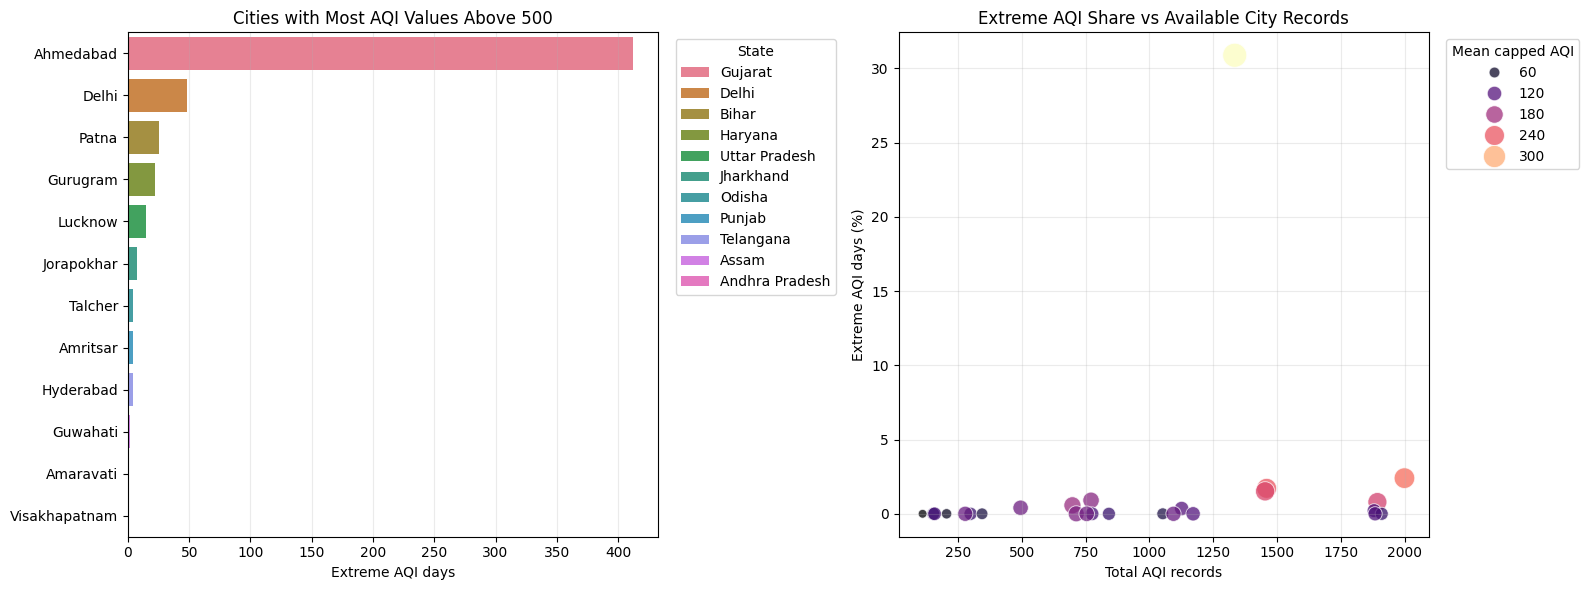

,State,City,extreme_days,records,mean_aqi,extreme_day_percent
6,Gujarat,Ahmedabad,412,1334,356.05,30.88
5,Delhi,Delhi,48,1999,258.06,2.40
3,Bihar,Patna,25,1459,240.08,1.71
7,Haryana,Gurugram,22,1453,223.66,1.51
24,Uttar Pradesh,Lucknow,15,1893,217.45,0.79
8,Jharkhand,Jorapokhar,7,771,158.71,0.91
18,Odisha,Talcher,4,698,172.71,0.57
19,Punjab,Amritsar,4,1126,119.18,0.36
23,Telangana,Hyderabad,4,1880,108.99,0.21
2,Assam,Guwahati,2,495,138.51,0.40


In [21]:
extreme_by_city = (
    city_final.assign(is_extreme=city_final["AQI"] > AQI_UPPER_LIMIT)
    .groupby(["State", "City"], as_index=False)
    .agg(extreme_days=("is_extreme", "sum"), records=("AQI", "size"), mean_aqi=("AQI_capped", "mean"))
    .assign(extreme_day_percent=lambda df: df["extreme_days"] / df["records"] * 100)
    .sort_values(["extreme_days", "extreme_day_percent"], ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=extreme_by_city.head(12),
    x="extreme_days",
    y="City",
    hue="State",
    dodge=False,
    ax=axes[0],
)
axes[0].set_title(f"Cities with Most AQI Values Above {AQI_UPPER_LIMIT}")
axes[0].set_xlabel("Extreme AQI days")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=extreme_by_city,
    x="records",
    y="extreme_day_percent",
    size="mean_aqi",
    hue="mean_aqi",
    palette="magma",
    sizes=(40, 300),
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("Extreme AQI Share vs Available City Records")
axes[1].set_xlabel("Total AQI records")
axes[1].set_ylabel("Extreme AQI days (%)")
axes[1].grid(alpha=0.25)
axes[1].legend(title="Mean capped AQI", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

display(extreme_by_city.head(12).round(2))

## Task 6: Is India's Air Getting Better or Worse Over Time?

Based on the available AQI data, India's city-level air quality appears to have improved over time, but the conclusion should be stated carefully because this file covers 2015-01-01 to 2020-07-01 rather than a full eight years. After converting `Date` to a year and averaging capped AQI values by year, the annual mean AQI falls steadily from 207.9 in 2015 to 112.4 in 2020. The most polluted year in this dataset is 2015, while the least polluted year is 2020. The years after 2018 are visibly lower than the earlier years, suggesting improvement after 2018; however, 2020 is only a partial year and may also reflect unusual COVID-period activity changes, so I would describe the evidence as a clear downward trend in the available data rather than final proof that policy alone caused the improvement.

,Year,mean_aqi,median_aqi,records,cities
0,2015,207.9,175.0,1827,7
1,2016,194.7,149.0,2573,9
2,2017,177.0,129.0,3234,15
3,2018,171.2,124.0,5724,18
4,2019,151.1,109.0,7071,23
5,2020,112.4,93.0,4421,26


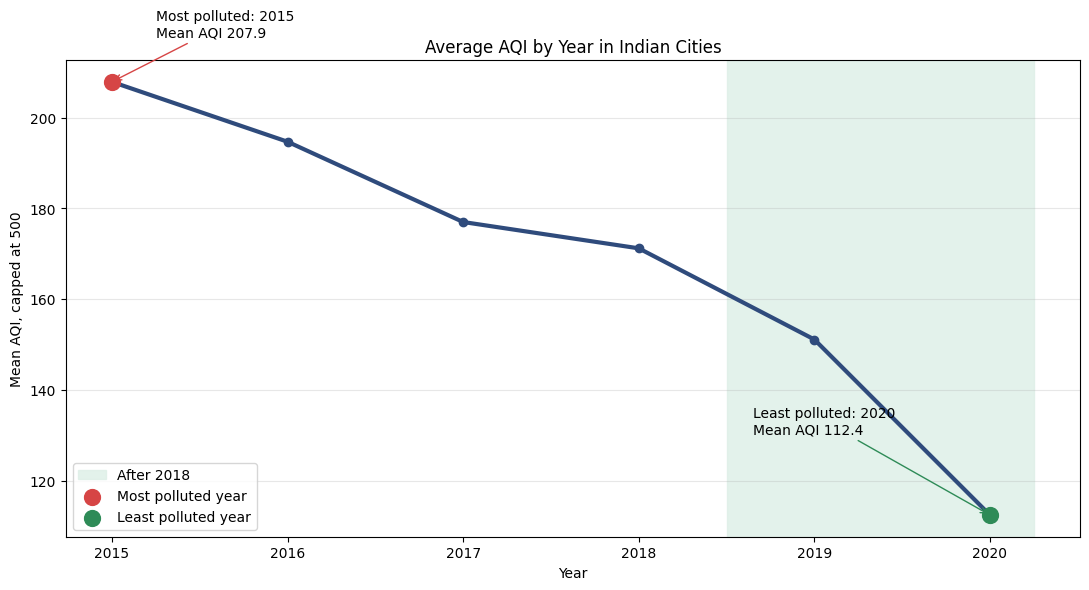

In [22]:
city_final["Year"] = city_final["Date"].dt.year

yearly_aqi = (
    city_final.dropna(subset=["Year"])
    .groupby("Year")
    .agg(
        mean_aqi=("AQI_capped", "mean"),
        median_aqi=("AQI_capped", "median"),
        records=("AQI_capped", "size"),
        cities=("City", "nunique"),
    )
    .reset_index()
)

yearly_aqi["mean_aqi"] = yearly_aqi["mean_aqi"].round(1)
yearly_aqi["median_aqi"] = yearly_aqi["median_aqi"].round(1)

most_polluted_year = yearly_aqi.loc[yearly_aqi["mean_aqi"].idxmax()]
least_polluted_year = yearly_aqi.loc[yearly_aqi["mean_aqi"].idxmin()]

display(yearly_aqi)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    yearly_aqi["Year"],
    yearly_aqi["mean_aqi"],
    marker="o",
    linewidth=3,
    color="#2F4B7C",
)
ax.axvspan(2018.5, yearly_aqi["Year"].max() + 0.25, color="#DDEFE7", alpha=0.8, label="After 2018")

ax.scatter(most_polluted_year["Year"], most_polluted_year["mean_aqi"], color="#D64545", s=130, zorder=5, label="Most polluted year")
ax.scatter(least_polluted_year["Year"], least_polluted_year["mean_aqi"], color="#2E8B57", s=130, zorder=5, label="Least polluted year")

ax.annotate(
    f"Most polluted: {int(most_polluted_year['Year'])}\nMean AQI {most_polluted_year['mean_aqi']:.1f}",
    xy=(most_polluted_year["Year"], most_polluted_year["mean_aqi"]),
    xytext=(most_polluted_year["Year"] + 0.25, most_polluted_year["mean_aqi"] + 10),
    arrowprops={"arrowstyle": "->", "color": "#D64545"},
    fontsize=10,
)
ax.annotate(
    f"Least polluted: {int(least_polluted_year['Year'])}\nMean AQI {least_polluted_year['mean_aqi']:.1f}",
    xy=(least_polluted_year["Year"], least_polluted_year["mean_aqi"]),
    xytext=(least_polluted_year["Year"] - 1.35, least_polluted_year["mean_aqi"] + 18),
    arrowprops={"arrowstyle": "->", "color": "#2E8B57"},
    fontsize=10,
)

ax.set_title("Average AQI by Year in Indian Cities")
ax.set_xlabel("Year")
ax.set_ylabel("Mean AQI, capped at 500")
ax.set_xticks(yearly_aqi["Year"])
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


## Task 7: Does AQI Get Worse During the October-December Harvest Season?

The data supports the NGO's claim that air quality is worse during the October-December harvest window. After extracting the month from `Date` and averaging capped AQI values by month, November has the highest average AQI at 227.5, followed closely by January at 223.0 and December at 222.2. The October-December harvest window has an average AQI of 209.9, compared with 145.8 across the other months, so AQI is clearly elevated during that period. The pattern is not exclusive to harvest season because January is also very polluted, but the evidence does show that October-December is one of the worst air-quality periods in the year.

,Month,Month_Name,mean_aqi,median_aqi,records,cities
0,1,Jan,223.0,183.0,2141,25
1,2,Feb,191.9,149.5,2078,25
2,3,Mar,156.8,124.0,2327,26
3,4,Apr,139.5,111.0,2295,26
4,5,May,134.9,111.0,2447,26
5,6,Jun,119.2,96.0,2344,26
6,7,Jul,110.2,86.0,1836,26
7,8,Aug,111.8,85.0,1776,21
8,9,Sep,113.5,88.0,1757,23
9,10,Oct,178.7,130.0,1889,23


,Harvest_Window,mean_aqi,median_aqi,records
0,Oct-Dec harvest window,209.9,164.0,5849
1,Other months,145.8,109.0,19001


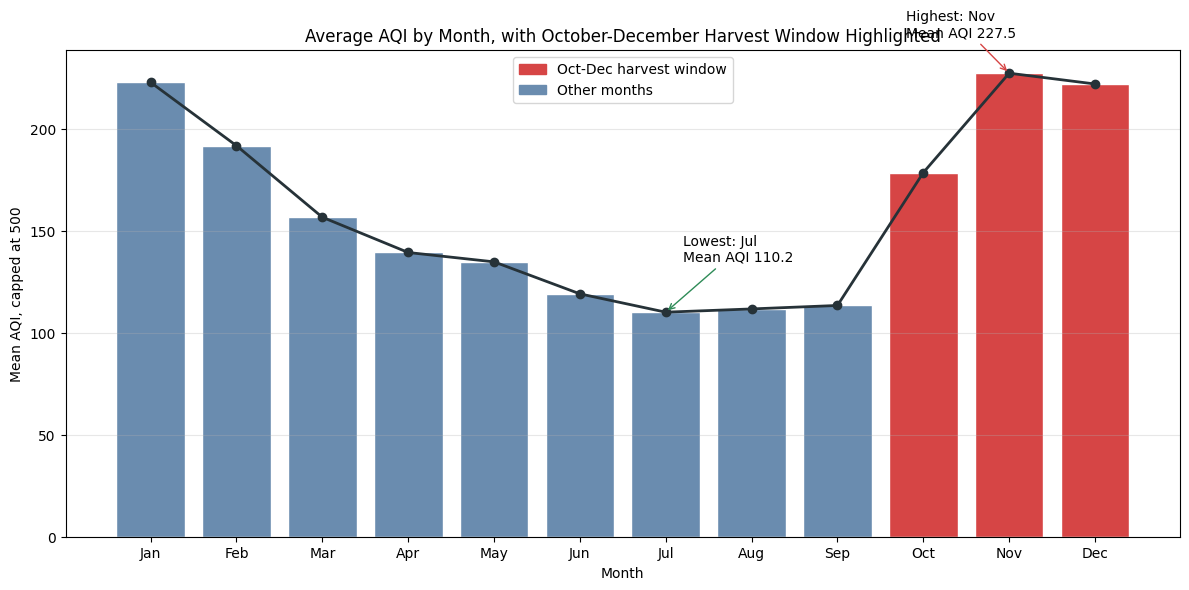

In [23]:
city_final["Month"] = city_final["Date"].dt.month
city_final["Month_Name"] = city_final["Date"].dt.strftime("%b")
city_final["Harvest_Window"] = np.where(
    city_final["Month"].isin([10, 11, 12]),
    "Oct-Dec harvest window",
    "Other months",
)

monthly_aqi = (
    city_final.groupby(["Month", "Month_Name"])
    .agg(
        mean_aqi=("AQI_capped", "mean"),
        median_aqi=("AQI_capped", "median"),
        records=("AQI_capped", "size"),
        cities=("City", "nunique"),
    )
    .reset_index()
    .sort_values("Month")
)
monthly_aqi["mean_aqi"] = monthly_aqi["mean_aqi"].round(1)
monthly_aqi["median_aqi"] = monthly_aqi["median_aqi"].round(1)

harvest_comparison = (
    city_final.groupby("Harvest_Window")
    .agg(
        mean_aqi=("AQI_capped", "mean"),
        median_aqi=("AQI_capped", "median"),
        records=("AQI_capped", "size"),
    )
    .reset_index()
)
harvest_comparison["mean_aqi"] = harvest_comparison["mean_aqi"].round(1)
harvest_comparison["median_aqi"] = harvest_comparison["median_aqi"].round(1)

display(monthly_aqi)
display(harvest_comparison)

highest_month = monthly_aqi.loc[monthly_aqi["mean_aqi"].idxmax()]
lowest_month = monthly_aqi.loc[monthly_aqi["mean_aqi"].idxmin()]
bar_colors = ["#D64545" if month in [10, 11, 12] else "#6A8CAF" for month in monthly_aqi["Month"]]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(monthly_aqi["Month_Name"], monthly_aqi["mean_aqi"], color=bar_colors, edgecolor="white")
ax.plot(monthly_aqi["Month_Name"], monthly_aqi["mean_aqi"], color="#263238", marker="o", linewidth=2)

ax.annotate(
    f"Highest: {highest_month['Month_Name']}\nMean AQI {highest_month['mean_aqi']:.1f}",
    xy=(highest_month["Month"] - 1, highest_month["mean_aqi"]),
    xytext=(highest_month["Month"] - 2.2, highest_month["mean_aqi"] + 18),
    arrowprops={"arrowstyle": "->", "color": "#D64545"},
    fontsize=10,
)
ax.annotate(
    f"Lowest: {lowest_month['Month_Name']}\nMean AQI {lowest_month['mean_aqi']:.1f}",
    xy=(lowest_month["Month"] - 1, lowest_month["mean_aqi"]),
    xytext=(lowest_month["Month"] - 0.8, lowest_month["mean_aqi"] + 25),
    arrowprops={"arrowstyle": "->", "color": "#2E8B57"},
    fontsize=10,
)

ax.set_title("Average AQI by Month, with October-December Harvest Window Highlighted")
ax.set_xlabel("Month")
ax.set_ylabel("Mean AQI, capped at 500")
ax.grid(axis="y", alpha=0.3)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#D64545", label="Oct-Dec harvest window"),
    plt.Rectangle((0, 0), 1, 1, color="#6A8CAF", label="Other months"),
]
ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()


## Task 8: Can the Two Datasets Talk to Each Other?

The two datasets cannot be merged row-by-row because they describe different units: AQI is city-day data, while crop production is state-year data. The first compatible option is a state-year merge, so I aggregate AQI from city-day to `State` + `Year` and crop records from district/crop/season rows to `State` + `Year`. However, a strict state-year merge produces no shared rows because the usable AQI states in 2015 do not overlap with the crop states available in 2015, and the crop file ends in 2015 while AQI continues after that. To still explore the main investigation question, I use a state-level merge: AQI is averaged by state across available AQI years, while crop production is converted to average annual state-level crop totals across available crop years. This makes the common key `State`, but the result should be treated as exploratory because the time periods do not fully align.

Rows from strict State-Year merge: 0
AQI state-years: 87 from 2015 to 2020
Crop state-years: 519 from 1997 to 2015
Rows from exploratory State-level merge: 20


,State,mean_aqi,avg_annual_production,avg_annual_area,avg_crop_count,avg_district_count,monitored_cities
0,Andhra Pradesh,108.09,9.624772e+08,7305962.17,39.78,13.00,2
1,Assam,138.51,1.173195e+08,3909930.67,30.44,25.22,1
2,Bihar,240.08,2.036020e+07,7126084.94,33.44,37.61,1
3,Chandigarh,96.50,4.919730e+03,961.69,6.85,1.00,1
4,Gujarat,356.05,3.276821e+07,9682882.75,27.50,23.06,1
5,Haryana,223.66,2.382962e+07,5594654.56,25.81,19.81,1
6,Jharkhand,158.71,1.539677e+06,1341578.03,10.43,21.71,1
7,Karnataka,94.32,4.796832e+07,11272699.39,41.50,27.78,1
8,Kerala,81.02,5.437780e+09,1766791.78,20.94,14.00,3
9,Madhya Pradesh,132.83,2.640240e+07,19399485.94,35.53,47.35,1


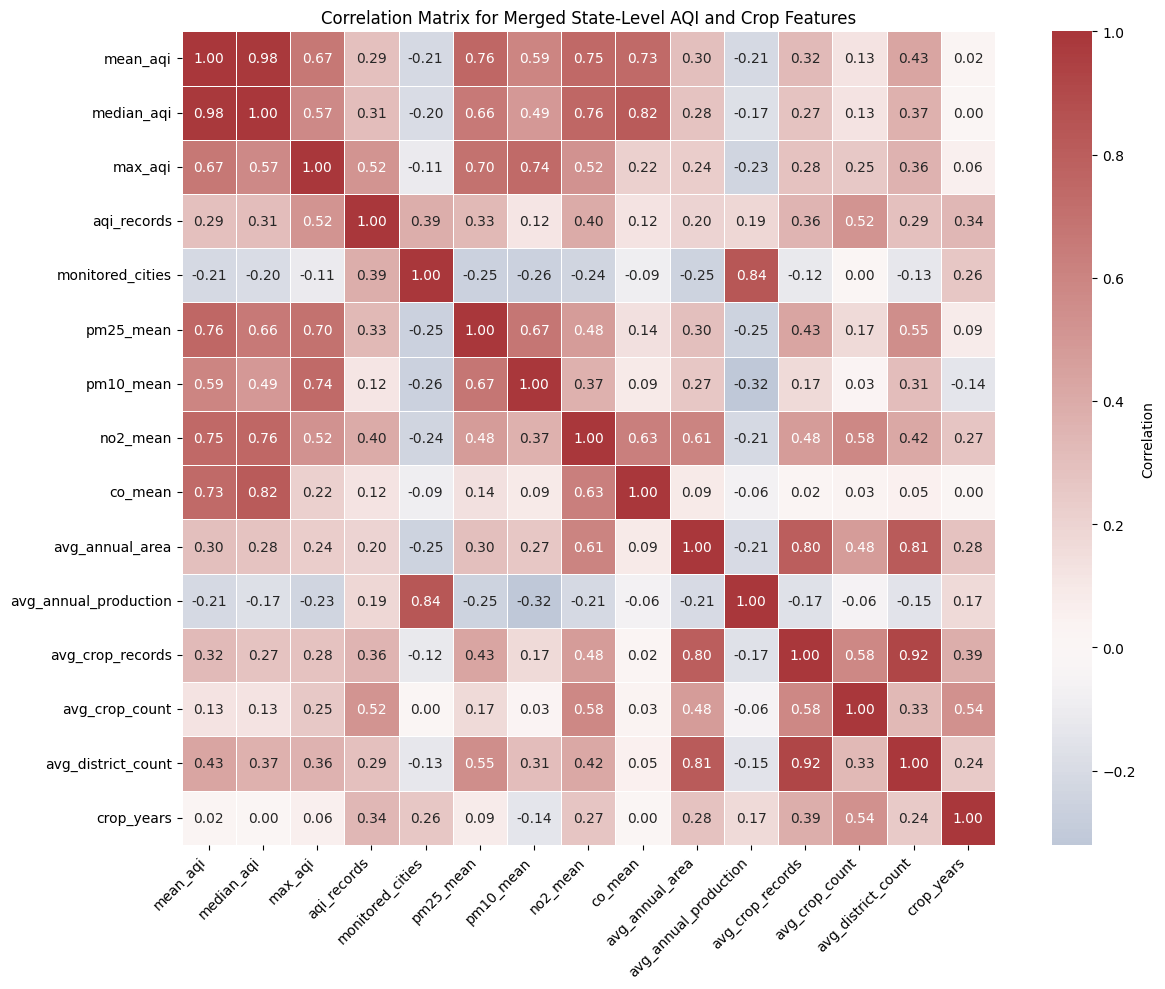

,mean_aqi,median_aqi,max_aqi,aqi_records,monitored_cities,pm25_mean,pm10_mean,no2_mean,co_mean,avg_annual_area,avg_annual_production,avg_crop_records,avg_crop_count,avg_district_count,crop_years
mean_aqi,1.00,0.98,0.67,0.29,-0.21,0.76,0.59,0.75,0.73,0.30,-0.21,0.32,0.13,0.43,0.02
median_aqi,0.98,1.00,0.57,0.31,-0.20,0.66,0.49,0.76,0.82,0.28,-0.17,0.27,0.13,0.37,0.00
max_aqi,0.67,0.57,1.00,0.52,-0.11,0.70,0.74,0.52,0.22,0.24,-0.23,0.28,0.25,0.36,0.06
aqi_records,0.29,0.31,0.52,1.00,0.39,0.33,0.12,0.40,0.12,0.20,0.19,0.36,0.52,0.29,0.34
monitored_cities,-0.21,-0.20,-0.11,0.39,1.00,-0.25,-0.26,-0.24,-0.09,-0.25,0.84,-0.12,0.00,-0.13,0.26
pm25_mean,0.76,0.66,0.70,0.33,-0.25,1.00,0.67,0.48,0.14,0.30,-0.25,0.43,0.17,0.55,0.09
pm10_mean,0.59,0.49,0.74,0.12,-0.26,0.67,1.00,0.37,0.09,0.27,-0.32,0.17,0.03,0.31,-0.14
no2_mean,0.75,0.76,0.52,0.40,-0.24,0.48,0.37,1.00,0.63,0.61,-0.21,0.48,0.58,0.42,0.27
co_mean,0.73,0.82,0.22,0.12,-0.09,0.14,0.09,0.63,1.00,0.09,-0.06,0.02,0.03,0.05,0.00
avg_annual_area,0.30,0.28,0.24,0.20,-0.25,0.30,0.27,0.61,0.09,1.00,-0.21,0.80,0.48,0.81,0.28


In [24]:
aqi_state_year = (
    city_final.dropna(subset=["State", "Year"])
    .groupby(["State", "Year"])
    .agg(mean_aqi=("AQI_capped", "mean"))
    .reset_index()
)

crop_state_year = (
    crop_merge_ready.groupby(["State", "Crop_Year"])
    .agg(total_production=("Production", "sum"))
    .reset_index()
    .rename(columns={"Crop_Year": "Year"})
)

strict_state_year_merge = pd.merge(
    aqi_state_year,
    crop_state_year,
    on=["State", "Year"],
    how="inner",
)

print(f"Rows from strict State-Year merge: {len(strict_state_year_merge):,}")
print("AQI state-years:", len(aqi_state_year), "from", int(aqi_state_year["Year"].min()), "to", int(aqi_state_year["Year"].max()))
print("Crop state-years:", len(crop_state_year), "from", int(crop_state_year["Year"].min()), "to", int(crop_state_year["Year"].max()))

aqi_state = (
    city_final.groupby("State")
    .agg(
        mean_aqi=("AQI_capped", "mean"),
        median_aqi=("AQI_capped", "median"),
        max_aqi=("AQI_capped", "max"),
        aqi_records=("AQI_capped", "size"),
        monitored_cities=("City", "nunique"),
        pm25_mean=("PM2.5", "mean"),
        pm10_mean=("PM10", "mean"),
        no2_mean=("NO2", "mean"),
        co_mean=("CO", "mean"),
    )
    .reset_index()
)

crop_year_state = (
    crop_merge_ready.groupby(["State", "Crop_Year"])
    .agg(
        total_area=("Area", "sum"),
        total_production=("Production", "sum"),
        crop_records=("Production", "size"),
        crop_count=("Crop", "nunique"),
        district_count=("District_Name", "nunique"),
    )
    .reset_index()
)

crop_state = (
    crop_year_state.groupby("State")
    .agg(
        avg_annual_area=("total_area", "mean"),
        avg_annual_production=("total_production", "mean"),
        avg_crop_records=("crop_records", "mean"),
        avg_crop_count=("crop_count", "mean"),
        avg_district_count=("district_count", "mean"),
        crop_years=("Crop_Year", "nunique"),
    )
    .reset_index()
)

combined_state = pd.merge(aqi_state, crop_state, on="State", how="inner")
print(f"Rows from exploratory State-level merge: {len(combined_state):,}")

display(
    combined_state[
        [
            "State", "mean_aqi", "avg_annual_production", "avg_annual_area",
            "avg_crop_count", "avg_district_count", "monitored_cities"
        ]
    ].round(2)
)

numeric_combined = combined_state.select_dtypes(include="number")
correlation_matrix = numeric_combined.corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation Matrix for Merged State-Level AQI and Crop Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(correlation_matrix.round(2))


### Two interesting relationships

First, the main investigation relationship, `mean_aqi` versus `avg_annual_production`, is only weakly negative at about -0.21. That means this merged state-level dataset does not show strong evidence that states with worse air quality consistently produce less crop. A likely real-world reason is that crop output is driven by many other factors, especially irrigation, crop mix, rainfall, cultivated area, and state size. The time mismatch between the AQI and crop files also weakens any conclusion.

Second, AQI has strong positive relationships with pollutant features such as `pm25_mean` (about 0.76), `no2_mean` (about 0.75), and `co_mean` (about 0.73). This makes real-world sense because AQI is calculated from pollutant concentrations, so states with higher particulate and gas pollution should also have higher overall AQI. The correlation matrix is useful for spotting these associations, but it does not prove causation.

## Task 9: Briefing for the State Environment Minister

Our analysis points to three clear findings. First, air quality in the city data appears to improve over time: average AQI falls from 207.9 in 2015 to 112.4 in 2020. This suggests recent years were cleaner, though 2020 is only a partial and unusual year. Second, air pollution is strongly seasonal. The October-December harvest period averages 209.9 AQI, compared with 145.8 in other months, and November is the worst month. On the ground, this means farmers and nearby communities face the dirtiest air around harvest time. Third, when we compare states, worse air does not clearly line up with lower crop production. Crop output depends on many other things, including rainfall, irrigation, crop choice, and land area.

My recommendation is to target October-December with practical support for residue management: subsidised machinery, collection centres, and fast local monitoring in high-risk districts. The honest limitation is that this data shows patterns, not proof that pollution alone reduces harvests. Better matched state-year farm and air data is needed before making that claim.